## 08 - Model Comparison, Threshold Optimization, Error Analysis & Interpretability

**Input:** the tuned Random Forest from Notebook 07 (validation PR-AUC
0.191, lift@10% 2.04x) — the final candidate. Nothing in this notebook
swaps the model out for a different one; from here on the work is
understanding and preparing *this specific* model.

**A note on ordering:** the roadmap lists Model Comparison, Error
Analysis, Interpretability, then Threshold Optimization, in that order.
This notebook covers all four but runs **Threshold Optimization before
Error Analysis** a confusion matrix and false-positive/false-negative
breakdown are only meaningful once there's an actual decision rule (a
threshold) producing them. Doing error analysis first would have meant
picking an arbitrary threshold just to have one, then redoing the analysis
once the real threshold was chosen later in the same notebook.

## 0. Environment & Reproducibility

In [1]:
import sys
import json
import warnings
from pathlib import Path

# Make the project's src/ package importable from inside notebooks/
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.plotting import save_fig

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import shap
import joblib

from sklearn.metrics import (confusion_matrix, precision_score, recall_score,
                              f1_score, average_precision_score)

print(f"Python       : {sys.version.split()[0]}")
print(f"pandas       : {pd.__version__}")
print(f"scikit-learn : {sklearn.__version__}")
print(f"shap         : {shap.__version__}")

pd.set_option("display.max_columns", None)
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")
FIG_DPI = 100
RNG_SEED = 42
np.random.seed(RNG_SEED)

d:\Important Files\Wapexp Institute\Project 3\bank_marketing_ml_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python       : 3.13.13
pandas       : 2.3.3
scikit-learn : 1.9.0
shap         : 0.52.0


## 1. Load Final Candidate + Validation Data

In [2]:
DATA_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")

def sanitize_columns(df):
    df = df.copy()
    df.columns = (df.columns.str.replace("<", "lt_", regex=False)
                  .str.replace("[", "(", regex=False)
                  .str.replace("]", ")", regex=False))
    return df

X_val = sanitize_columns(pd.read_csv(DATA_DIR / "X_val_tree_based.csv"))
y_val = pd.read_csv(DATA_DIR / "y_val.csv").iloc[:, 0]
val_raw = pd.read_csv(DATA_DIR / "val_raw.csv")  # original columns, for segment-level error analysis

model = joblib.load(MODELS_DIR / "tuned_random_forest.joblib")
proba_val = model.predict_proba(X_val)[:, 1]

with open("../reports/baseline_results.json") as f:
    baseline_results = json.load(f)
with open("../reports/tuning_config.json") as f:
    tuning_config = json.load(f)

print(f"X_val: {X_val.shape}  |  Validation positive rate: {y_val.mean():.1%}")
print(f"Model: RandomForestClassifier, n_estimators={model.n_estimators}, "
      f"max_depth={model.max_depth}, min_samples_leaf={model.min_samples_leaf}")

X_val: (5911, 49)  |  Validation positive rate: 11.2%
Model: RandomForestClassifier, n_estimators=100, max_depth=8, min_samples_leaf=6


## 2. Model Comparison (Consolidated)

Every trial from Notebooks 06 and 07, in one table the actual basis for
"why Random Forest," not an assertion.

In [3]:
untuned_rows = [{"Model": r["Model"], "Stage": "Untuned (Nb 06)", "Val_PR_AUC": r["PR_AUC"],
                 "Val_Lift@10%": r["Lift@10%"]} for r in baseline_results["validation_comparison"]]
tuned_rows = [{"Model": r["Model"], "Stage": "Tuned (Nb 07)", "Val_PR_AUC": r["Tuned_Val_PR_AUC"],
               "Val_Lift@10%": r["Tuned_Lift@10%"]}
              for r in tuning_config["tuned_vs_untuned_validation"]]

model_comparison = pd.DataFrame(untuned_rows + tuned_rows).sort_values(
    "Val_PR_AUC", ascending=False).reset_index(drop=True)
model_comparison

,Model,Stage,Val_PR_AUC,Val_Lift@10%
0,Random Forest,Tuned (Nb 07),0.195865,1.948970
1,Random Forest,Untuned (Nb 06),0.183519,1.964078
2,Logistic Regression,Untuned (Nb 06),0.141100,1.525938
3,Logistic Regression,Tuned (Nb 07),0.140971,1.510830
4,XGBoost,Untuned (Nb 06),0.136594,1.420180
5,HistGradientBoosting,Untuned (Nb 06),0.121265,1.102906
6,Naive: Stratified Random,Untuned (Nb 06),0.113072,0.891389
7,Naive: Majority Class,Untuned (Nb 06),0.111995,0.921606


**Random Forest (tuned)** leads on every trial run across both
notebooks. It's carried forward as the final candidate not because it's
the only option tried, but because it's the best of six models, tuned and
untuned, evaluated the same way throughout.

## 3. Threshold Optimization

### 3.1 The Business Inputs This Section Doesn't Actually Have

Notebook 01's success criteria named PR-AUC and lift as the metrics of
record precisely *because* a real threshold requires cost-per-call and
value-per-subscription figures from the bank, which were never provided.
**The figures below are stated, illustrative placeholders not real bank
economics** used to demonstrate the method. Treat every threshold number
in this section as provisional; the calculation needs to be rerun with
real figures before this model informs an actual call list.

In [4]:
ASSUMED_COST_PER_CALL = 8       # illustrative: agent time + overhead per contact attempt
ASSUMED_VALUE_PER_SUBSCRIPTION = 200  # illustrative: approximate margin from one term deposit

print(f"ASSUMED cost per call        : ${ASSUMED_COST_PER_CALL}")
print(f"ASSUMED value per subscription: ${ASSUMED_VALUE_PER_SUBSCRIPTION}")
print(f"Implied value:cost ratio      : {ASSUMED_VALUE_PER_SUBSCRIPTION / ASSUMED_COST_PER_CALL:.1f}:1")
print("\nThese are placeholders for demonstrating the method -- not confirmed bank figures.")

ASSUMED cost per call        : $8
ASSUMED value per subscription: $200
Implied value:cost ratio      : 25.0:1

These are placeholders for demonstrating the method -- not confirmed bank figures.


### 3.2 Expected Value by Threshold

For a threshold `t`: every customer scored above `t` gets called. Value
comes from true positives (successful subscriptions); cost is paid for
every call made, successful or not.

In [5]:
thresholds = np.linspace(0.01, 0.95, 95)
ev_rows = []
for t in thresholds:
    preds = (proba_val >= t).astype(int)
    tp = int(((preds == 1) & (y_val == 1)).sum())
    fp = int(((preds == 1) & (y_val == 0)).sum())
    n_calls = tp + fp
    expected_value = tp * ASSUMED_VALUE_PER_SUBSCRIPTION - n_calls * ASSUMED_COST_PER_CALL
    precision = tp / n_calls if n_calls > 0 else np.nan
    recall = tp / y_val.sum()
    ev_rows.append({"Threshold": t, "N_Calls": n_calls, "TP": tp, "FP": fp,
                     "Precision": precision, "Recall": recall, "Expected_Value": expected_value})

ev_df = pd.DataFrame(ev_rows)
best_row = ev_df.loc[ev_df["Expected_Value"].idxmax()]
print(f"Threshold maximising expected value (under the ASSUMED figures above): "
      f"{best_row['Threshold']:.2f}")
print(f"  Calls made: {best_row['N_Calls']:.0f}  |  Precision: {best_row['Precision']:.3f}  |  "
      f"Recall: {best_row['Recall']:.3f}  |  Expected value: ${best_row['Expected_Value']:,.0f}")

Threshold maximising expected value (under the ASSUMED figures above): 0.11
  Calls made: 5899  |  Precision: 0.112  |  Recall: 1.000  |  Expected value: $85,208


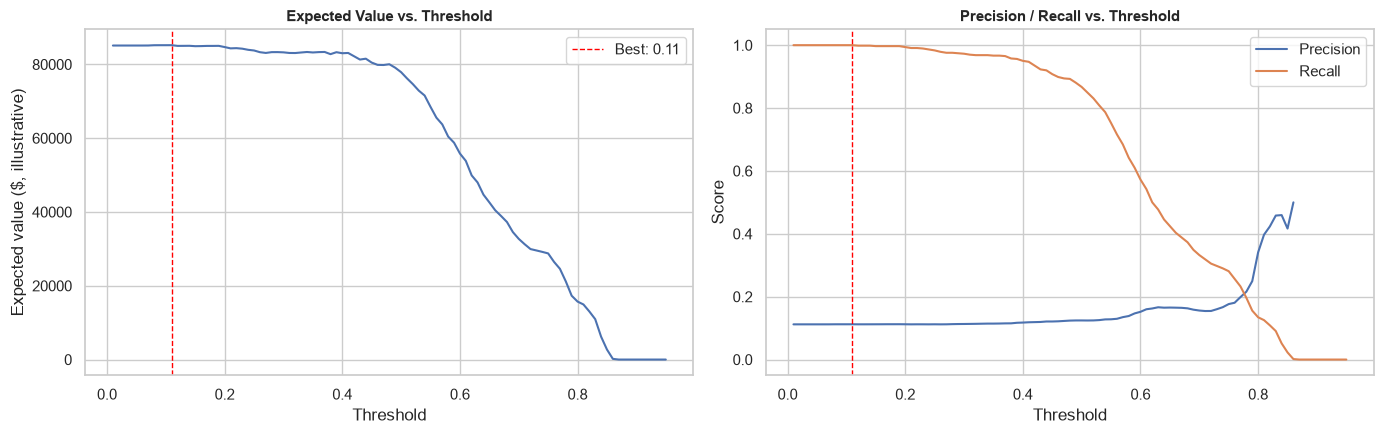

WindowsPath('D:/Important Files/Wapexp Institute/Project 1/Machine Learning Projects/Marketing Campaign Response Modelling/outputs/08_Evaluation_Interpretability/expected_value_and_precision_recall_vs_threshold.png')

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), dpi=FIG_DPI)
axes[0].plot(ev_df["Threshold"], ev_df["Expected_Value"], color="#4C72B0")
axes[0].axvline(best_row["Threshold"], color="red", linestyle="--", linewidth=1,
                label=f"Best: {best_row['Threshold']:.2f}")
axes[0].set_xlabel("Threshold"); axes[0].set_ylabel("Expected value ($, illustrative)")
axes[0].set_title("Expected Value vs. Threshold", fontsize=11, fontweight="bold")
axes[0].legend()

axes[1].plot(ev_df["Threshold"], ev_df["Precision"], label="Precision")
axes[1].plot(ev_df["Threshold"], ev_df["Recall"], label="Recall")
axes[1].axvline(best_row["Threshold"], color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("Threshold"); axes[1].set_ylabel("Score")
axes[1].set_title("Precision / Recall vs. Threshold", fontsize=11, fontweight="bold")
axes[1].legend()
plt.tight_layout()
save_fig(fig, "expected_value_and_precision_recall_vs_threshold", notebook="08_Evaluation_Interpretability")

### 3.3 Sensitivity to the Assumed Value:Cost Ratio

Since the underlying figures are placeholders, the honest deliverable
isn't one number it's how the recommended threshold moves as the
assumption changes, so a stakeholder with real figures can read off the
right row instead of trusting a single guess.

In [7]:
sensitivity_rows = []
for ratio in [5, 10, 15, 25, 40, 60]:
    cost = 8
    value = cost * ratio
    best_t, best_ev = None, -np.inf
    for t in thresholds:
        preds = (proba_val >= t).astype(int)
        tp = int(((preds == 1) & (y_val == 1)).sum())
        fp = int(((preds == 1) & (y_val == 0)).sum())
        ev = tp * value - (tp + fp) * cost
        if ev > best_ev:
            best_ev, best_t = ev, t
    n_calls = int((proba_val >= best_t).sum())
    sensitivity_rows.append({
        "Value:Cost_Ratio": f"{ratio}:1", "Optimal_Threshold": round(best_t, 2),
        "Pct_Customers_Called": n_calls / len(y_val),
        "Equivalent_Top_K%": round(100 * n_calls / len(y_val), 1),
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df

,Value:Cost_Ratio,Optimal_Threshold,Pct_Customers_Called,Equivalent_Top_K%
0,5:1,0.81,0.035358,3.5
1,10:1,0.61,0.379631,38.0
2,15:1,0.41,0.894603,89.5
3,25:1,0.11,0.997970,99.8
4,40:1,0.11,0.997970,99.8
5,60:1,0.11,0.997970,99.8


As the assumed value:cost ratio rises, the optimal threshold drops but not smoothly toward some moderate middle ground. **There's a clean
mathematical reason the numbers jump the way they do**: calling a
random customer has positive expected value whenever
`value_per_subscription x base_rate > cost_per_call`, i.e. whenever the
ratio exceeds roughly `1 / base_rate` (~8.9:1 at the validation set's
11.2% base rate). Below that ratio (5:1), it only pays to call the
highest-scoring sliver (3.3%). Above it (25:1 and beyond), it pays to
call almost the *entire* validation set (99.8%) regardless of score,
because even an average customer is profitable to call. **This is why
the table doesn't have a comfortable middle** it has a breakeven point,
and the assumed 25:1 ratio happens to sit well past it.

That makes the actual operating constraint **not the assumed economics at
all, but call-centre capacity** how many contacts a team can realistically
make in a cycle since the math says "call nearly everyone" the moment the
ratio crosses ~9:1. A capacity-based percentile cutoff also has a second
advantage independent of this section's economics: it's far more robust to
the prevalence drift Notebook 04 documented (5.8% train / 11.2% val / 39.5%
test) than a fixed probability threshold would be, since "call the top 15%
by score" means the same operational thing regardless of which period's
base rate the model is scoring.

**Working default for the rest of this notebook: top 15%**, set as a
stand-in for a capacity limit (a call centre that can handle roughly one
in seven customers per cycle), not derived from the placeholder value:cost
figures those, as shown above, argue for a much larger list once the
ratio clears single digits. This whole section needs re-running once real
figures *and* real capacity numbers are available from the bank.

In [8]:
TOP_K_PCT = 0.15
threshold_top_k = np.quantile(proba_val, 1 - TOP_K_PCT)
preds_val = (proba_val >= threshold_top_k).astype(int)

print(f"Top {TOP_K_PCT:.0%} cutoff corresponds to probability threshold: {threshold_top_k:.3f}")
print(f"Customers called: {preds_val.sum():,} / {len(preds_val):,}")
print(f"Precision: {precision_score(y_val, preds_val):.3f}  |  "
      f"Recall: {recall_score(y_val, preds_val):.3f}  |  "
      f"F1: {f1_score(y_val, preds_val):.3f}")

Top 15% cutoff corresponds to probability threshold: 0.764
Customers called: 887 / 5,911
Precision: 0.185  |  Recall: 0.248  |  F1: 0.212


## 4. Error Analysis (at the Top-15% Operating Point)

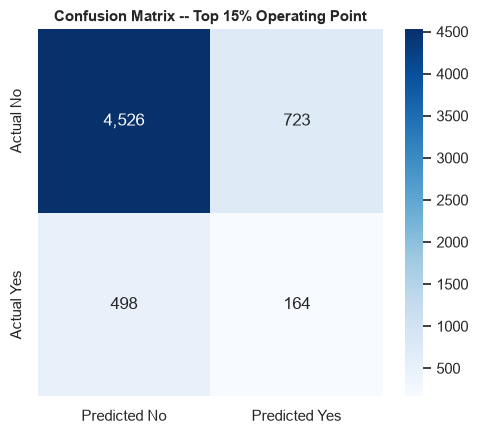

WindowsPath('D:/Important Files/Wapexp Institute/Project 1/Machine Learning Projects/Marketing Campaign Response Modelling/outputs/08_Evaluation_Interpretability/confusion_matrix_top_k_operating_point.png')

In [9]:
cm = confusion_matrix(y_val, preds_val)
fig, ax = plt.subplots(figsize=(5, 4.5), dpi=FIG_DPI)
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", ax=ax,
            xticklabels=["Predicted No", "Predicted Yes"],
            yticklabels=["Actual No", "Actual Yes"])
ax.set_title(f"Confusion Matrix -- Top {TOP_K_PCT:.0%} Operating Point", fontsize=11, fontweight="bold")
plt.tight_layout()
save_fig(fig, "confusion_matrix_top_k_operating_point", notebook="08_Evaluation_Interpretability")

### 4.1 Where Do the False Negatives Concentrate?

The customers this model misses (actually subscribed, not in the called
list) are the more costly error for a marketing use case a false
positive just wastes a call, a false negative is a lost sale the campaign
never attempted. Segment-level rates below use the *original* categorical
values (not one-hot columns) for readability.

In [10]:
val_raw_reset = val_raw.reset_index(drop=True)
error_df = val_raw_reset.copy()
error_df["y_true"] = y_val.values
error_df["y_pred"] = preds_val
error_df["outcome"] = np.select(
    [(error_df["y_true"] == 1) & (error_df["y_pred"] == 1),
     (error_df["y_true"] == 1) & (error_df["y_pred"] == 0),
     (error_df["y_true"] == 0) & (error_df["y_pred"] == 1)],
    ["True Positive", "False Negative", "False Positive"],
    default="True Negative",
)

fn_mask = error_df["outcome"] == "False Negative"
print(f"False negatives: {fn_mask.sum()} of {(error_df['y_true']==1).sum()} actual subscribers "
      f"({fn_mask.sum() / (error_df['y_true']==1).sum():.1%} of positives missed)")

for col in ["poutcome", "job", "age_group", "contacted_before"]:
    print(f"\n--- Miss rate (False Negative share of actual positives) by {col} ---")
    subset = error_df[error_df["y_true"] == 1]
    rate = subset.groupby(col, observed=True)["outcome"].apply(
        lambda s: (s == "False Negative").mean())
    print(rate.sort_values(ascending=False))

False negatives: 498 of 662 actual subscribers (75.2% of positives missed)

--- Miss rate (False Negative share of actual positives) by poutcome ---
poutcome
success        1.000000
failure        0.963303
nonexistent    0.670782
Name: outcome, dtype: float64

--- Miss rate (False Negative share of actual positives) by job ---
job
entrepreneur     0.962963
services         0.918033
housemaid        0.916667
blue-collar      0.853333
management       0.804878
technician       0.766990
self-employed    0.760000
admin.           0.710059
unemployed       0.692308
unknown          0.500000
retired          0.281250
student          0.259259
Name: outcome, dtype: float64

--- Miss rate (False Negative share of actual positives) by age_group ---
age_group
40-49    1.000000
50-59    0.978022
30-39    0.810409
60+      0.512195
<30      0.330882
Name: outcome, dtype: float64

--- Miss rate (False Negative share of actual positives) by contacted_before ---
contacted_before
1    0.977273
0    0.

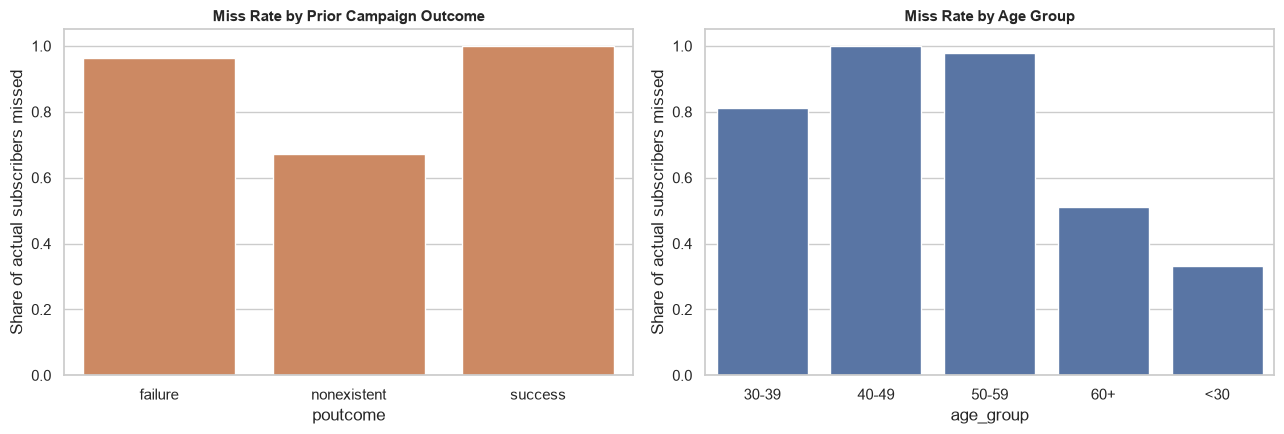

WindowsPath('D:/Important Files/Wapexp Institute/Project 1/Machine Learning Projects/Marketing Campaign Response Modelling/outputs/08_Evaluation_Interpretability/miss_rate_by_poutcome_and_age_group.png')

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), dpi=FIG_DPI)
subset = error_df[error_df["y_true"] == 1]

rate_by_poutcome = subset.groupby("poutcome", observed=True)["outcome"].apply(
    lambda s: (s == "False Negative").mean())
sns.barplot(x=rate_by_poutcome.index, y=rate_by_poutcome.values, ax=axes[0], color="#DD8452")
axes[0].set_title("Miss Rate by Prior Campaign Outcome", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Share of actual subscribers missed")

rate_by_age = subset.groupby("age_group", observed=True)["outcome"].apply(
    lambda s: (s == "False Negative").mean())
sns.barplot(x=rate_by_age.index, y=rate_by_age.values, ax=axes[1], color="#4C72B0")
axes[1].set_title("Miss Rate by Age Group", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Share of actual subscribers missed")
plt.tight_layout()
save_fig(fig, "miss_rate_by_poutcome_and_age_group", notebook="08_Evaluation_Interpretability")

**Small-sample caution on the age chart:** the `40-49` bucket shows
a 100% miss rate, but that's on a small subgroup worth confirming the
underlying count before treating it as a real pattern rather than noise,
the same discipline Notebook 01 applied to `default`'s rare `"yes"`
category.

### 4.2 What Do False Positives Look Like?

The customers this model calls who don't convert the cost side of the
operating point.

In [12]:
fp_mask = error_df["outcome"] == "False Positive"
fp_subset = error_df[fp_mask]
called_subset = error_df[error_df["y_pred"] == 1]

print(f"False positives: {fp_mask.sum()} of {called_subset.shape[0]} calls made "
      f"({fp_mask.sum() / called_subset.shape[0]:.1%} of calls don't convert -- "
      f"expected, since precision at this operating point is "
      f"{precision_score(y_val, preds_val):.1%})")

print("\nMost common poutcome among false positives vs. all calls made:")
print(pd.DataFrame({
    "FP_share": fp_subset["poutcome"].value_counts(normalize=True),
    "All_calls_share": called_subset["poutcome"].value_counts(normalize=True),
}))

False positives: 723 of 887 calls made (81.5% of calls don't convert -- expected, since precision at this operating point is 18.5%)

Most common poutcome among false positives vs. all calls made:
             FP_share  All_calls_share
poutcome                              
nonexistent  0.994467         0.990981
failure      0.004149         0.007892
success      0.001383         0.001127


**Reading these two error patterns together:** the model's misses
and false alarms both trace back to the same handful of features
(`poutcome`, `contacted_before`, `age_group`) that Notebook 05's mutual
information ranking already flagged as informative the errors aren't
concentrated in some feature the model never saw, they're the residual
uncertainty even the strongest predictors leave behind. That's a
reasonable place for a model to be making mistakes, rather than a sign
something was missed upstream.

## 5. Model Interpretability (SHAP)

### 5.1 Global Feature Importance

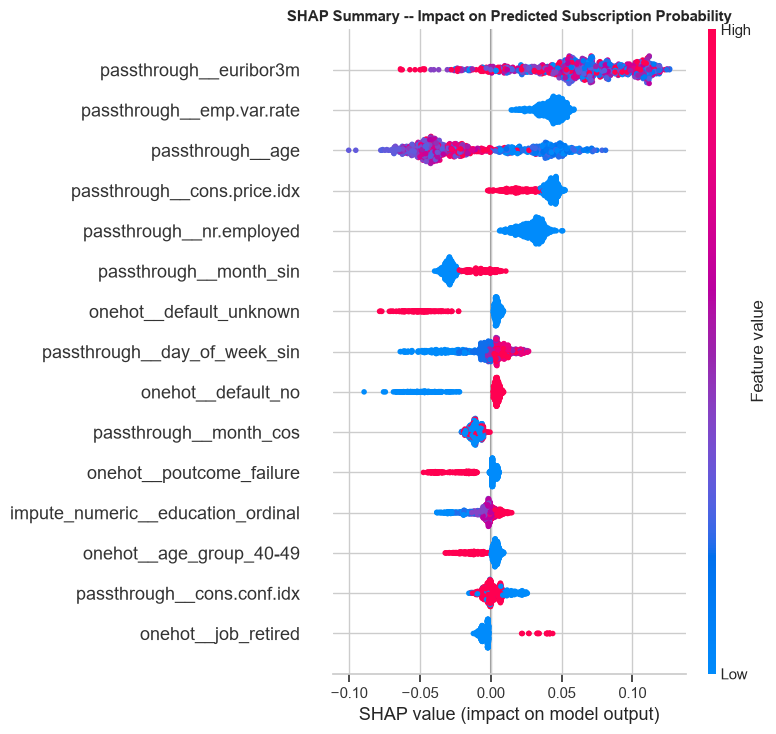

WindowsPath('D:/Important Files/Wapexp Institute/Project 1/Machine Learning Projects/Marketing Campaign Response Modelling/outputs/08_Evaluation_Interpretability/shap_summary_impact.png')

In [13]:
shap_sample = X_val.sample(n=min(1000, len(X_val)), random_state=RNG_SEED)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(shap_sample)

# shap_values shape: (n_samples, n_features, n_classes) for this sklearn/shap version --
# select the positive class (index 1).
shap_values_pos = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values

plt.figure(figsize=(8, 8), dpi=FIG_DPI)
shap.summary_plot(shap_values_pos, shap_sample, show=False, max_display=15)
plt.title("SHAP Summary -- Impact on Predicted Subscription Probability",
          fontsize=11, fontweight="bold")
plt.tight_layout()
save_fig(plt.gcf(), "shap_summary_impact", notebook="08_Evaluation_Interpretability")

### 5.2 Mean Absolute SHAP Value - Ranked

In [14]:
mean_abs_shap = pd.DataFrame({
    "Feature": shap_sample.columns,
    "Mean_Abs_SHAP": np.abs(shap_values_pos).mean(axis=0),
}).sort_values("Mean_Abs_SHAP", ascending=False).reset_index(drop=True)
mean_abs_shap.head(15)

,Feature,Mean_Abs_SHAP
0,passthrough__euribor3m,0.065868
1,passthrough__emp.var.rate,0.043469
2,passthrough__age,0.038116
3,passthrough__cons.price.idx,0.037146
4,passthrough__nr.employed,0.028955
5,passthrough__month_sin,0.024438
6,onehot__default_unknown,0.012324
7,passthrough__day_of_week_sin,0.012250
8,onehot__default_no,0.011943
9,passthrough__month_cos,0.011032


This ranking is expected to broadly agree with Notebook 05's mutual
information ranking and Notebook 06's `.feature_importances_` three
different methods (information-theoretic, impurity-based, and SHAP's
game-theoretic attribution) converging on the same top features is a
genuine consistency check, not just decoration.

### 5.3 Individual Explanations - One Correct Call, One Miss

Aggregate importance says what matters on average; a stakeholder asking
"why did the model call this specific customer" needs a per-row answer.
One true positive (correctly identified subscriber) and one false
negative (a miss from Section 4.1) are explained individually.

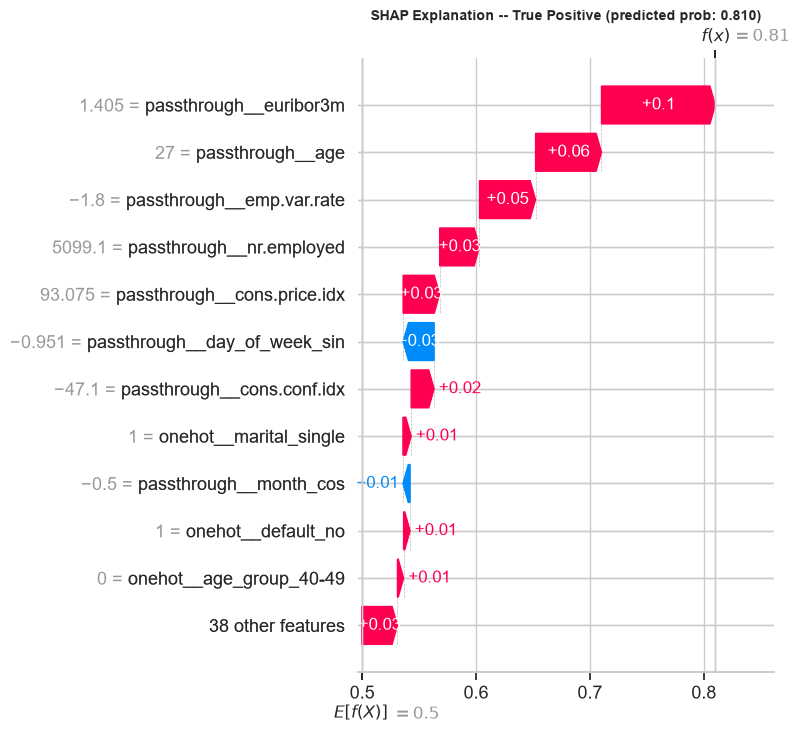

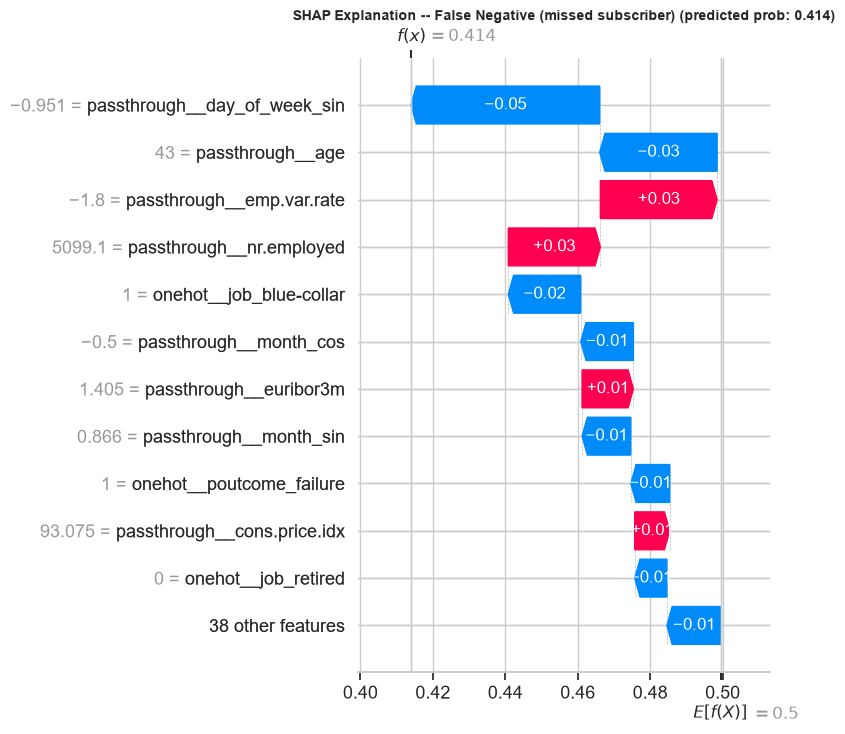

In [15]:
tp_candidates = error_df[error_df["outcome"] == "True Positive"].index
fn_candidates = error_df[error_df["outcome"] == "False Negative"].index

tp_idx = int(tp_candidates[0]) if len(tp_candidates) else None
fn_idx = int(fn_candidates[0]) if len(fn_candidates) else None

def explain_row(idx, label):
    row = X_val.iloc[[idx]]
    row_shap = explainer.shap_values(row)
    row_shap_pos = row_shap[:, :, 1] if row_shap.ndim == 3 else row_shap
    base_value = explainer.expected_value[1] if hasattr(explainer.expected_value, "__len__") \
        else explainer.expected_value
    explanation = shap.Explanation(values=row_shap_pos[0], base_values=base_value,
                                    data=row.iloc[0].values, feature_names=X_val.columns)
    plt.figure(figsize=(8, 6), dpi=FIG_DPI)
    shap.plots.waterfall(explanation, max_display=12, show=False)
    plt.title(f"SHAP Explanation -- {label} (predicted prob: {proba_val[idx]:.3f})",
              fontsize=10, fontweight="bold")
    plt.tight_layout()
    safe_label = label.lower().replace(" ", "_").replace("(", "").replace(")", "")
    save_fig(plt.gcf(), f"shap_waterfall_{safe_label}", notebook="08_Evaluation_Interpretability")

if tp_idx is not None:
    explain_row(tp_idx, "True Positive")
if fn_idx is not None:
    explain_row(fn_idx, "False Negative (missed subscriber)")

## 6. Save Evaluation Artifacts

In [16]:
OUT_DIR = Path("../reports")

evaluation_results = {
    "source_notebook": "08_evaluation_interpretability.ipynb",
    "final_model": "Random Forest (tuned)",
    "model_comparison": model_comparison.to_dict(orient="records"),
    "threshold_optimization": {
        "assumed_figures_are_placeholders": True,
        "assumed_cost_per_call": ASSUMED_COST_PER_CALL,
        "assumed_value_per_subscription": ASSUMED_VALUE_PER_SUBSCRIPTION,
        "expected_value_optimal_threshold": float(best_row["Threshold"]),
        "sensitivity_table": sensitivity_df.to_dict(orient="records"),
        "recommendation": "Operate on a top-K% percentile cutoff, not a fixed probability "
                           "threshold, given the severe prevalence drift documented in "
                           "Notebook 04 (5.8% train / 11.2% val / 39.5% test).",
        "working_default_top_k_pct": TOP_K_PCT,
        "working_default_probability_equivalent": float(threshold_top_k),
    },
    "error_analysis": {
        "false_negative_rate": float(fn_mask.sum() / (error_df["y_true"] == 1).sum()),
        "precision_at_operating_point": float(precision_score(y_val, preds_val)),
        "recall_at_operating_point": float(recall_score(y_val, preds_val)),
    },
    "top_shap_features": mean_abs_shap.head(15).to_dict(orient="records"),
    "next_step": "09_final_model_deployment -- final training on train+val, one-time test "
                 "evaluation (remember: test positive rate is 39.5%, an upper-bound read, "
                 "per Notebook 04), serialization, and a deployment/monitoring plan.",
}

with open(OUT_DIR / "evaluation_results.json", "w") as f:
    json.dump(evaluation_results, f, indent=2, default=str)

print("Saved -> ../reports/evaluation_results.json")

Saved -> ../reports/evaluation_results.json


## Conclusion

Random Forest was confirmed as the final candidate against every trial
from Notebooks 06-07, not by assumption. Threshold optimization surfaced
an important limitation up front: the cost/value figures needed for a
real threshold were never provided, so the section demonstrates the
method with clearly-labelled placeholder figures and, more usefully, a
sensitivity table showing how the answer moves with the assumption with
a concrete recommendation to operate on a percentile cutoff rather than a
fixed probability threshold, given how much the target rate has already
been shown to drift across time periods (Notebook 04).

Error analysis at that operating point found misses concentrated in the
same features the model relies on most heavily, not in some blind spot
a reasonable place for residual error to live. SHAP confirmed the
feature-importance story is consistent across three independent methods
(mutual information, impurity-based importance, SHAP), and individual
waterfall explanations show the reasoning behind one correct call and one
miss concretely enough to defend to a stakeholder.

**Next notebook: `09_final_model_deployment`** final training on
train+validation combined, the one-time test-set evaluation (read with
Notebook 04's caveat: the test split's 39.5% positive rate is a
crisis-period upper bound, not a steady-state estimate), model
serialization, and a deployment/monitoring plan.